In [2]:
from ultralytics import YOLO
import numpy as np
import cv2
import torch
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch import nn
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import timm
import torch.optim as optim
import os
from datetime import datetime
from torch_geometric.nn import GCNConv

/home/hice1/axu39/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class LizardDataset(Dataset):
    def __init__(self, pt_paths, input_size=512, heatmap_size=512):
        self.paths = pt_paths
        self.input_size = input_size
        self.heatmap_size = heatmap_size

        self.transform = A.Compose([
            A.LongestMaxSize(max_size=input_size),
            A.PadIfNeeded(input_size, input_size, border_mode=cv2.BORDER_CONSTANT),
            A.Affine(
                scale=(0.9, 1.1),
                translate_percent=(0.05, 0.05),
                rotate=(-25, 25),
                p=0.8
            ),
            A.OneOf([
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2),
                A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10)
            ], p=0.7),
            #A.ElasticTransform(alpha=10, sigma=5, p=0.2),
            A.GaussNoise(var_limit=(1,5), p=0.3),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
        ], keypoint_params=A.KeypointParams(format="xy", remove_invisible=False, label_fields=[]))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        data = torch.load(self.paths[idx])
        img = data["image"].permute(1,2,0).numpy()
        coords = data["tps"].numpy()  # shape (9,2)

        # Clip coords inside original image bounds
        H, W = img.shape[:2]
        coords[:,0] = np.clip(coords[:,0], 0, W-1)
        coords[:,1] = np.clip(coords[:,1], 0, H-1)
        keypoints = [(float(pt[0]), float(pt[1])) for pt in coords]
        #print(data)
        orig_size = data["orig_size"]
        augmented = self.transform(image=img, keypoints=keypoints)
        
        img_aug = augmented["image"]
        kp_aug = np.array(augmented["keypoints"], dtype=np.float32)
        #print(kp_aug.shape)
        if kp_aug.shape[0] != 9:
            raise ValueError(f"Augmented keypoints shape mismatch: {kp_aug.shape}, expected 9")

        # Clamp and normalize
        kp_aug[:,0] = np.clip(kp_aug[:,0], 0, self.input_size-1)
        kp_aug[:,1] = np.clip(kp_aug[:,1], 0, self.input_size-1)
        coords_norm = kp_aug / self.input_size

        img_tensor = torch.from_numpy(img_aug).permute(2,0,1).float()
        coords_tensor = torch.from_numpy(coords_norm).float()

        return img_tensor, coords_tensor, orig_size
    

class HRNetGNN(nn.Module):
    def __init__(self, hrnet_backbone, feat_dim=64, gnn_hidden=128, num_layers=2, num_landmarks=9, num_iters=3):
        super().__init__()
        self.num_landmarks = num_landmarks
        self.num_iters = num_iters
        
        self.backbone = timm.create_model(
            "hrnet_w18",
            pretrained=True,
            features_only=True
        )
        
        self.feat_dim = feat_dim
        self.backbone_out_idx = -1
        
        self.node_feat_proj = nn.Linear(self.backbone.feature_info[self.backbone_out_idx]['num_chs'], gnn_hidden)
        
        self.gnn_layers = nn.ModuleList()
        for _ in range(num_layers):
            self. gnn_layers.append(GCNConv(gnn_hidden, gnn_hidden))
            
        self.delta_head = nn.Linear(gnn_hidden, 2)
        
    def sample_features(self, feat_map, coords):
        B, C, H, W = feat_map.shape
        N = coords.shape[1]
        grid = coords.clone()
        
        grid = (grid * 2) - 1
        grid = grid.unsqueeze(2)
        
        sampled = F.grid_sample(feat_map, grid, align_corners=True)
        sampled = sampled.squeeze(-1).permute(0, 2, 1)
        return sampled
    
    def forward(self, x, initial_coords, edge_index):
        coords = initial_coords.clone()
        feat_maps = self.backbone(x)
        feat_map = feat_maps[self.backbone_out_idx]
        
        for _ in range(self.num_iters):
            node_feats = self.sample_features(feat_map, coords)
            node_feats = self.node_feat_proj(node_feats)
            node_feats = F.relu(node_feats)
            B, N, F_dim = node_feats.shape
            node_feats_flat = node_feats.view(B*N, F_dim)
            batch_edge_index = []
            for b in range(B):
                batch_edge_index.append(edge_index + b*N)
            batch_edge_index = torch.cat(batch_edge_index, dim=1)
            
            h = node_feats_flat
            for layer in self.gnn_layers:
                h = layer(h, batch_edge_index)
                h = F.relu(h)
                
            delta = self.delta_head(h)
            delta = delta.view(B, N, 2)
            
            coords = coords + delta
            
        return coords
              

In [4]:
def make_chain_edge_index(num_landmarks=9):
    edges = []
    for i in range(num_landmarks - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])
    edge_index = torch.tensor(edges, dtype=torch.long).t()
    return edge_index

def landmark_loss(pred_coords, gt_coords):
    coord_loss = F.mse_loss(pred_coords, gt_coords)
    pred_dists = (pred_coords[:, 1:] - pred_coords[:, :-1]).norm(dim=-1)
    
    gt_dists = (gt_coords[:, 1:] - gt_coords[:, :-1]).norm(dim=-1)
    dist_loss = F.mse_loss(pred_dists, gt_dists)
    
    return coord_loss + 0.5 * dist_loss
    

def visualize_landmarks(img_tensor, pred_coords, gt_coords=None, save_path="./vis.jpg"):
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = (img * 255).astype('uint8')
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    
    pred_xy = pred_coords.cpu().numpy() * img.shape[1]
    plt.scatter(pred_xy[:,0], pred_xy[:,1], c='r', label='pred', s=30)
    
    if gt_coords is not None:
        gt_xy = gt_coords.cpu().numpy() * img.shape[1]
        plt.scatter(gt_xy[:, 0], gt_xy[:, 1], c='g', label="gt", s=30, marker='x')
        
    plt.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()
    
def compute_rescaled_pixel_error(pred_coords, coords, orig_size, device="cuda"):
    # coords are normalized [0,1], so convert to 512 space
    pred_px = pred_coords * 512
    gt_px = coords * 512
    orig_h = orig_size[:, 0]  # shape: (B,)
    orig_w = orig_size[:, 1]  # shape: (B,)
    # compute per-axis scale
    scale_x = 512 / orig_w.view(-1,1,1)
    scale_y = 512 / orig_h.view(-1,1,1)
    
    scale_x = scale_x.to(device)
    scale_y = scale_y.to(device)
    
    # rescale errors back to crop space
    dx = (pred_px[:,:,0] - gt_px[:,:,0]) / scale_x.squeeze(-1)
    dy = (pred_px[:,:,1] - gt_px[:,:,1]) / scale_y.squeeze(-1)

    error = torch.sqrt(dx**2 + dy**2)  # (B, num_points)

    return error.mean(dim=1).sum().item()

def train(model, train_dataset, val_dataset=None, device='cuda', epochs=10, batch_size=4, lr=1e-4):
    model = model.to(device)
    model.train()
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    edge_index = make_chain_edge_index(num_landmarks=train_dataset[0][1].shape[0]).to(device)
    best_val = 10000
    for epoch in range(epochs):
        epoch_loss = 0.0
        for imgs, coords, _ in train_loader:
            imgs = imgs.to(device)
            coords = coords.to(device)
            B = imgs.shape[0]
            #initial_coords = coords.clone() + ( torch.rand_like(coords)  * 0.03 )
            mean_shape = torch.tensor([
                [0.3, 0.9], [0.4, 0.8], [0.5, 0.7],
                [0.6, 0.6], [0.7, 0.5], [0.8, 0.4],
                [0.7, 0.3], [0.6, 0.2], [0.5, 0.1],
            ], dtype=torch.float).to(imgs.device)

            initial_coords = mean_shape.unsqueeze(0).repeat(B,1,1)
            
            pred_coords = model(imgs, initial_coords, edge_index)
            loss = landmark_loss(pred_coords, coords)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * imgs.size(0)
            
        epoch_loss /= len(train_dataset)        
        val_loss = None
        pix_err = None
        if val_dataset is not None:
            model.eval()
            val_loader = DataLoader(val_dataset, batch_size=batch_size)
            val_loss_total = 0.0
            pxerr_total = 0.0
            with torch.no_grad():
                for imgs, coords, orig_size in val_loader:
                    imgs = imgs.to(device)
                    coords = coords.to(device)
                    B = imgs.shape[0]
                    #initial_coords = coords.clone()
                    mean_shape = torch.tensor([
                        [0.3, 0.9], [0.4, 0.8], [0.5, 0.7],
                        [0.6, 0.6], [0.7, 0.5], [0.8, 0.4],
                        [0.7, 0.3], [0.6, 0.2], [0.5, 0.1],
                    ], dtype=torch.float).to(imgs.device)

                    initial_coords = mean_shape.unsqueeze(0).repeat(B,1,1)
                    pred_coords = model(imgs, initial_coords, edge_index)
                    val_loss_total += landmark_loss(pred_coords, coords).item() * imgs.size(0)
                    pxerr_total += compute_rescaled_pixel_error(pred_coords, coords, orig_size, device)
                    
            val_loss = val_loss_total / len(val_dataset)
            pix_err = pxerr_total / len(val_dataset)
            
            if val_loss < best_val:
                best_val = val_loss
                torch.save(model.state_dict(), "./best_gnn.pth")
            
            model.train()
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_loss:.6f}, Avg Pixel Error: {pix_err}" +
             (f", Val Loss: {val_loss:.6f}" if val_loss is not None else ""))
        
        if epoch % 10 == 0:
            visualize_landmarks(imgs[0], pred_coords[0], coords[0])
        
    return model
    

/tmp/ipykernel_1750871/1797768844.py:21: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(1,5), p=0.3),
Unexpected keys (downsamp_modules.0.1.num_batches_tracked, downsamp_modules.1.1.num_batches_tracked, downsamp_modules.2.1.num_batches_tracked, final_layer.1.num_batches_tracked, downsamp_modules.0.0.bias, downsamp_modules.0.0.weight, downsamp_modules.0.1.bias, downsamp_modules.0.1.running_mean, downsamp_modules.0.1.running_var, downsamp_modules.0.1.weight, downsamp_modules.1.0.bias, downsamp_modules.1.0.weight, downsamp_modules.1.1.bias, downsamp_modules.1.1.running_mean, downsamp_modules.1.1.running_var, downsamp_modules.1.1.weight, downsamp_modules.2.0.bias, downsamp_modules.2.0.weight, downsamp_modules.2.1.bias, downsamp_modules.2.1.running_mean, downsamp_modules.2.1.running_var, downsamp_modules.2.1.weight, final_layer.0.bias, final_layer.0.weight, final_layer.1.bias, final_layer.1.running_mean, final_layer.1.running_var, final

Epoch 1/80, Train Loss: 0.089915, Avg Pixel Error: 81.30164687321904, Val Loss: 0.030277


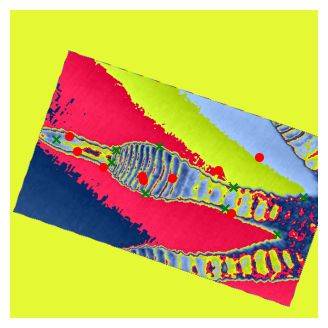

Epoch 2/80, Train Loss: 0.022042, Avg Pixel Error: 61.62232743932846, Val Loss: 0.018685
Epoch 3/80, Train Loss: 0.016702, Avg Pixel Error: 48.343153933261306, Val Loss: 0.014275
Epoch 4/80, Train Loss: 0.012033, Avg Pixel Error: 40.8298818478106, Val Loss: 0.010955
Epoch 5/80, Train Loss: 0.009851, Avg Pixel Error: 35.85739478948993, Val Loss: 0.008748
Epoch 6/80, Train Loss: 0.007794, Avg Pixel Error: 32.55788117846457, Val Loss: 0.007029
Epoch 7/80, Train Loss: 0.006283, Avg Pixel Error: 31.232625433739194, Val Loss: 0.006108
Epoch 8/80, Train Loss: 0.005734, Avg Pixel Error: 31.74045486218299, Val Loss: 0.006862
Epoch 9/80, Train Loss: 0.006414, Avg Pixel Error: 33.2574463818211, Val Loss: 0.006106
Epoch 10/80, Train Loss: 0.005048, Avg Pixel Error: 26.78871201164454, Val Loss: 0.004837
Epoch 11/80, Train Loss: 0.004466, Avg Pixel Error: 26.571929189571858, Val Loss: 0.004555


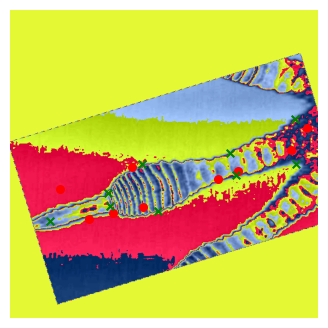

Epoch 12/80, Train Loss: 0.004090, Avg Pixel Error: 25.242105779676812, Val Loss: 0.004521
Epoch 13/80, Train Loss: 0.003897, Avg Pixel Error: 23.569235479940396, Val Loss: 0.003785
Epoch 14/80, Train Loss: 0.003403, Avg Pixel Error: 22.6577914159711, Val Loss: 0.003457
Epoch 15/80, Train Loss: 0.003368, Avg Pixel Error: 20.821123766681705, Val Loss: 0.003194
Epoch 16/80, Train Loss: 0.003244, Avg Pixel Error: 20.082517954353865, Val Loss: 0.002990
Epoch 17/80, Train Loss: 0.002805, Avg Pixel Error: 19.28279285372934, Val Loss: 0.002694
Epoch 18/80, Train Loss: 0.002417, Avg Pixel Error: 16.694057151539347, Val Loss: 0.001927
Epoch 19/80, Train Loss: 0.002255, Avg Pixel Error: 15.64570575934413, Val Loss: 0.001635
Epoch 20/80, Train Loss: 0.001578, Avg Pixel Error: 14.071240874409312, Val Loss: 0.001461
Epoch 21/80, Train Loss: 0.001584, Avg Pixel Error: 13.452154489998398, Val Loss: 0.001455


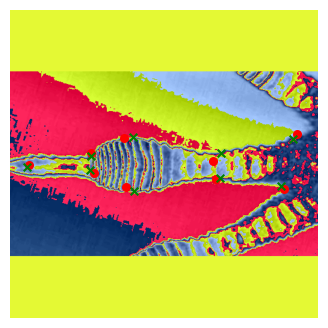

Epoch 22/80, Train Loss: 0.001142, Avg Pixel Error: 12.41515514988305, Val Loss: 0.001156
Epoch 23/80, Train Loss: 0.001116, Avg Pixel Error: 12.251596607335795, Val Loss: 0.001050
Epoch 24/80, Train Loss: 0.001089, Avg Pixel Error: 10.670398932459868, Val Loss: 0.000869
Epoch 25/80, Train Loss: 0.002716, Avg Pixel Error: 20.019325975226778, Val Loss: 0.003840
Epoch 26/80, Train Loss: 0.002246, Avg Pixel Error: 14.16686867942926, Val Loss: 0.001929
Epoch 27/80, Train Loss: 0.001546, Avg Pixel Error: 11.827683515461745, Val Loss: 0.001067
Epoch 28/80, Train Loss: 0.000953, Avg Pixel Error: 10.682953135945514, Val Loss: 0.000873
Epoch 29/80, Train Loss: 0.000870, Avg Pixel Error: 9.934350567385781, Val Loss: 0.000769
Epoch 30/80, Train Loss: 0.000779, Avg Pixel Error: 9.716393722951594, Val Loss: 0.000756
Epoch 31/80, Train Loss: 0.001245, Avg Pixel Error: 13.220723021718868, Val Loss: 0.001287


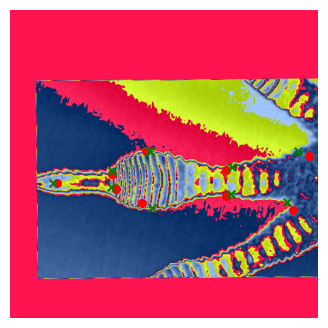

Epoch 32/80, Train Loss: 0.001218, Avg Pixel Error: 12.659040688743707, Val Loss: 0.001281
Epoch 33/80, Train Loss: 0.001128, Avg Pixel Error: 10.782646364716411, Val Loss: 0.000983
Epoch 34/80, Train Loss: 0.002448, Avg Pixel Error: 18.489588496895184, Val Loss: 0.002728
Epoch 35/80, Train Loss: 0.001595, Avg Pixel Error: 12.839927882046686, Val Loss: 0.001218
Epoch 36/80, Train Loss: 0.001128, Avg Pixel Error: 10.414141947737582, Val Loss: 0.000812
Epoch 37/80, Train Loss: 0.000870, Avg Pixel Error: 10.287796020507812, Val Loss: 0.000775
Epoch 38/80, Train Loss: 0.000860, Avg Pixel Error: 10.17897587924018, Val Loss: 0.000813
Epoch 39/80, Train Loss: 0.000796, Avg Pixel Error: 9.570833061241451, Val Loss: 0.000721
Epoch 40/80, Train Loss: 0.000688, Avg Pixel Error: 9.092477259302575, Val Loss: 0.000623
Epoch 41/80, Train Loss: 0.000667, Avg Pixel Error: 9.239351498682085, Val Loss: 0.000656


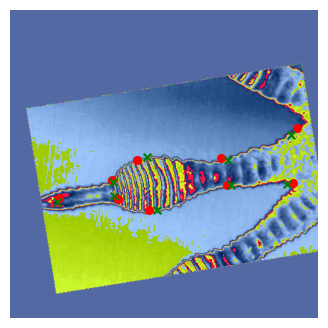

Epoch 42/80, Train Loss: 0.002155, Avg Pixel Error: 133.7247678066822, Val Loss: 0.063218
Epoch 43/80, Train Loss: 0.010950, Avg Pixel Error: 22.028728728598736, Val Loss: 0.003276
Epoch 44/80, Train Loss: 0.002698, Avg Pixel Error: 16.677767350680924, Val Loss: 0.001910
Epoch 45/80, Train Loss: 0.002019, Avg Pixel Error: 14.199566386028627, Val Loss: 0.001501
Epoch 46/80, Train Loss: 0.001359, Avg Pixel Error: 12.03328952963229, Val Loss: 0.001207
Epoch 47/80, Train Loss: 0.001454, Avg Pixel Error: 14.05348882704158, Val Loss: 0.001386
Epoch 48/80, Train Loss: 0.001268, Avg Pixel Error: 11.73344583714262, Val Loss: 0.001070
Epoch 49/80, Train Loss: 0.001066, Avg Pixel Error: 10.903987826547361, Val Loss: 0.000939
Epoch 50/80, Train Loss: 0.000919, Avg Pixel Error: 10.25380551416461, Val Loss: 0.000815
Epoch 51/80, Train Loss: 0.000800, Avg Pixel Error: 9.661141995601016, Val Loss: 0.000701


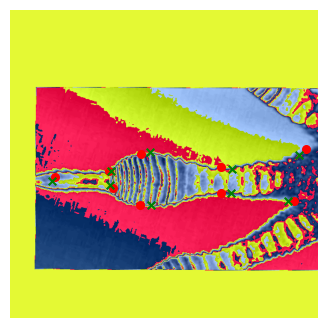

Epoch 52/80, Train Loss: 0.000764, Avg Pixel Error: 9.992492235177918, Val Loss: 0.000757
Epoch 53/80, Train Loss: 0.000750, Avg Pixel Error: 9.279395384629085, Val Loss: 0.000635
Epoch 54/80, Train Loss: 0.000678, Avg Pixel Error: 9.304008043283387, Val Loss: 0.000616
Epoch 55/80, Train Loss: 0.000696, Avg Pixel Error: 9.386401098187571, Val Loss: 0.000636
Epoch 56/80, Train Loss: 0.000657, Avg Pixel Error: 8.849943676980432, Val Loss: 0.000589
Epoch 57/80, Train Loss: 0.000631, Avg Pixel Error: 8.930106815233781, Val Loss: 0.000581
Epoch 58/80, Train Loss: 0.000646, Avg Pixel Error: 8.469167089027474, Val Loss: 0.000538
Epoch 59/80, Train Loss: 0.000594, Avg Pixel Error: 8.658582067054818, Val Loss: 0.000557
Epoch 60/80, Train Loss: 0.000582, Avg Pixel Error: 8.863407285742484, Val Loss: 0.000621
Epoch 61/80, Train Loss: 0.000566, Avg Pixel Error: 8.394546647926957, Val Loss: 0.000514


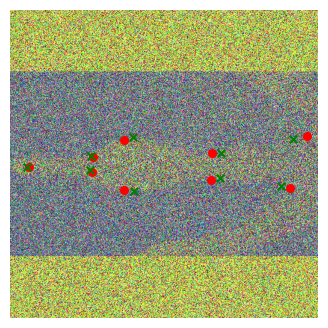

Epoch 62/80, Train Loss: 0.000577, Avg Pixel Error: 9.054743317485219, Val Loss: 0.000634
Epoch 63/80, Train Loss: 0.000728, Avg Pixel Error: 9.161059069416082, Val Loss: 0.000634
Epoch 64/80, Train Loss: 0.000592, Avg Pixel Error: 8.44244695506922, Val Loss: 0.000529
Epoch 65/80, Train Loss: 0.000543, Avg Pixel Error: 8.203649503481786, Val Loss: 0.000504
Epoch 66/80, Train Loss: 0.000536, Avg Pixel Error: 8.279240987945835, Val Loss: 0.000513
Epoch 67/80, Train Loss: 0.000566, Avg Pixel Error: 9.915567647360016, Val Loss: 0.000646
Epoch 68/80, Train Loss: 0.001030, Avg Pixel Error: 9.72782795914763, Val Loss: 0.000690
Epoch 69/80, Train Loss: 0.000638, Avg Pixel Error: 8.508207466102299, Val Loss: 0.000557
Epoch 70/80, Train Loss: 0.000601, Avg Pixel Error: 8.495034354073661, Val Loss: 0.000555
Epoch 71/80, Train Loss: 0.000566, Avg Pixel Error: 8.614105618833408, Val Loss: 0.000598


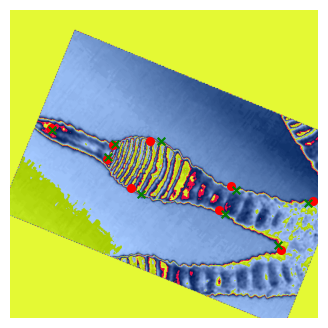

Epoch 72/80, Train Loss: 0.000601, Avg Pixel Error: 8.66959990991285, Val Loss: 0.000570
Epoch 73/80, Train Loss: 0.000545, Avg Pixel Error: 8.217114178967693, Val Loss: 0.000494
Epoch 74/80, Train Loss: 0.000529, Avg Pixel Error: 8.29501161894175, Val Loss: 0.000527
Epoch 75/80, Train Loss: 0.000521, Avg Pixel Error: 7.832313073804675, Val Loss: 0.000478
Epoch 76/80, Train Loss: 0.000522, Avg Pixel Error: 8.066051657076665, Val Loss: 0.000499
Epoch 77/80, Train Loss: 0.000507, Avg Pixel Error: 7.938913223591257, Val Loss: 0.000475
Epoch 78/80, Train Loss: 0.000502, Avg Pixel Error: 8.079811015027635, Val Loss: 0.000500
Epoch 79/80, Train Loss: 0.000497, Avg Pixel Error: 8.007356730637941, Val Loss: 0.000482
Epoch 80/80, Train Loss: 0.000483, Avg Pixel Error: 8.152336236553714, Val Loss: 0.000486


In [24]:
DATA_PATH = "/home/hice1/axu39/lizard/Lizard_Toepads/stacked-hourglass/data/hrnet/heatmaps/"
pt_paths = [os.path.join(DATA_PATH,f) for f in os.listdir(DATA_PATH) if f.endswith(".pt")]

dataset = LizardDataset(pt_paths, input_size=512)
train_size = int(0.8 * len(dataset))

val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

model = HRNetGNN(hrnet_backbone="hrnet_w18", feat_dim=1024, gnn_hidden=128,
                num_layers=3, num_landmarks=9, num_iters=6)

trained_model = train(model, train_dataset, val_dataset=val_dataset,
                     device='cuda' if torch.cuda.is_available() else 'cpu',
                     epochs=80, batch_size=32, lr=1e-4)

In [9]:
model = HRNetGNN(hrnet_backbone="hrnet_w18", feat_dim=1024, gnn_hidden=128,
                num_layers=3, num_landmarks=9, num_iters=6).to("cuda")
model.load_state_dict(torch.load("best_gnn.pth"))
model.eval()

mean_shape = torch.tensor([
    [0.3, 0.9], [0.4, 0.8], [0.5, 0.7],
    [0.6, 0.6], [0.7, 0.5], [0.8, 0.4],
    [0.7, 0.3], [0.6, 0.2], [0.5, 0.1],
])

initial_coords = mean_shape.unsqueeze(0).to('cuda')
edge_index = make_chain_edge_index(num_landmarks=9).to('cuda')
transform = A.Compose([
    A.LongestMaxSize(max_size=512),
    A.PadIfNeeded(512, 512, border_mode=cv2.BORDER_CONSTANT),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))


Unexpected keys (downsamp_modules.0.1.num_batches_tracked, downsamp_modules.1.1.num_batches_tracked, downsamp_modules.2.1.num_batches_tracked, final_layer.1.num_batches_tracked, downsamp_modules.0.0.bias, downsamp_modules.0.0.weight, downsamp_modules.0.1.bias, downsamp_modules.0.1.running_mean, downsamp_modules.0.1.running_var, downsamp_modules.0.1.weight, downsamp_modules.1.0.bias, downsamp_modules.1.0.weight, downsamp_modules.1.1.bias, downsamp_modules.1.1.running_mean, downsamp_modules.1.1.running_var, downsamp_modules.1.1.weight, downsamp_modules.2.0.bias, downsamp_modules.2.0.weight, downsamp_modules.2.1.bias, downsamp_modules.2.1.running_mean, downsamp_modules.2.1.running_var, downsamp_modules.2.1.weight, final_layer.0.bias, final_layer.0.weight, final_layer.1.bias, final_layer.1.running_mean, final_layer.1.running_var, final_layer.1.weight, classifier.bias, classifier.weight) found while loading pretrained weights. This may be expected if model is being adapted.


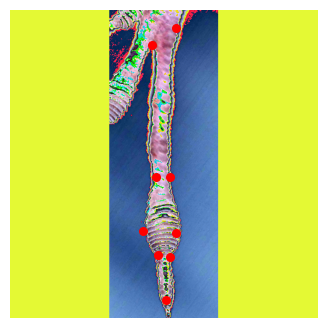

In [10]:
#trained_model.eval()
p = "/home/hice1/axu39/lizard/Lizard_Toepads/stacked-hourglass/data/raw_data/test_data/"
img = cv2.imread(f"{p}1039_toe.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

aug = transform(image=img_rgb, keypoints=[])
img_input = torch.from_numpy(aug['image']).permute(2,0,1).unsqueeze(0).float()
img_input = img_input.to('cuda')

with torch.no_grad():
    pred_coords = model(img_input, initial_coords, edge_index)
    pred_coords = pred_coords[0]

visualize_landmarks(img_input[0], pred_coords, gt_coords=None)
    


In [ ]:
def undo_letterbox(pred_coords, scale, pad_x, pad_y):
    coords = pred_coords.clone()

    coords[:, 0] = (coords[:, 0] - pad_x) / scale
    coords[:, 1] = (coords[:, 1] - pad_y) / scale

    return coords

def invert_perspective(coords, M):
    """Properly invert perspective transform for 3x3 homography matrix"""
    coords_np = coords.cpu().numpy()
    
    # Convert to homogeneous coordinates
    ones = np.ones((coords_np.shape[0], 1))
    coords_h = np.hstack([coords_np, ones])  # (N,3)
    
    # Invert the 3x3 perspective matrix
    M_inv = cv2.invert(M)[1]  # cv2.invert returns (retval, M_inv)
    
    # Apply inverse transform
    global_coords_h = (M_inv @ coords_h.T).T
    
    # Convert back from homogeneous (divide by w)
    global_coords = global_coords_h[:, :2] / global_coords_h[:, 2:3]
    
    return global_coords

def run_inference_on_pt(pt_path, model, device="cuda"):
    data = torch.load(pt_path)

    img = data["image"].unsqueeze(0).to(device)  # (1,3,512,512)
    scale = data["scale"].item()
    pad_x, pad_y = data["pad"].tolist()
    M = data["M"].numpy()

    # ---- forward pass ----
    with torch.no_grad():
        pred_coords = model(img, initial_coords, edge_index)
        pred_coords = pred_coords[0].cpu()  # (N,2)

    # ---- step 1: undo padding + scaling ----
    coords_crop = undo_letterbox(pred_coords, scale, pad_x, pad_y)

    # ---- step 2: map back to global ----
    coords_global = invert_perspective(coords_crop, M)

    return coords_global, coords_crop, pred_coords

In [26]:
from glob import glob

mlmorphdir = "/home/hice1/axu39/lizard/Lizard_Toepads/stacked-hourglass/data/hrnet/mlmorphcomp/"
pt_files = glob(f"{mlmorphdir}*.pt")

curid = ""
curimg = None
for pt_path in pt_files:
    coords_global, coords_crop, coords_model = run_inference_on_pt(pt_path, model)
    
    stem = Path(pt_path).stem
    
    sp = stem.split("_")
    iid = sp[0]
    
    if iid != curid:
        if curimg is not None:
            #img_rgb = cv2.cvtColor(curimg, cv2.COLOR_BGR2RGB)
            save_path = f"./{iid}_update.jpg"
            cv2.imwrite(save_path, curimg)

        
        curimg = cv2.imread(f"{mlmorphdir}comp_{iid}.jpg").copy()
    
    for i, (x, y) in enumerate(coords_global):
        pt = (int(x), int(y))
        cv2.circle(curimg, pt, 4, (0, 255, 0), -1)
        cv2.putText(curimg, str(i), (pt[0]+5, pt[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,255), 1)
    
    